In [ ]:
import sys
from pathlib import Path

projeto_raiz = Path("~/Documentos/ESPECT_CONV").expanduser().resolve()

if str(projeto_raiz) not in sys.path:
    sys.path.append(str(projeto_raiz))

# ==========================================================
# CONFIGURAÇÕES DE CAMINHO & IMPORTS LOCAIS
# ==========================================================

from pipeline.stage_20_load_and_epoching.stage_20_load_and_epoching import load_and_epoching

from pipeline.stage_30_psd_array_assembly.channels_2D_distribution import CENTRALIZED_ONE_BY_ONE_2D_DISTRIBUTION
from pipeline.stage_30_psd_array_assembly.stage_30_psd_array_assembly import psd_array_assembly
from pipeline.stage_40_obtain_indices.obtain_indices import obtain_indices
from pipeline.stage_50_execute_branch.execute_branch import execute_branch
from pipeline.stage_60_execute_fusion.execute_fusion import execute_fusion


CONDITION = "PRONOUNCED_SPEECH"


# Stage 20: Load and Epoching

In [ ]:

EPOCH_START_SECONDS = 1.0
EPOCH_END_SECONDS = 3.5

# ======================================================
# CONDITION OPTIONS
# ======================================================
#
# "PRONOUNCED_SPEECH"
#
# "INNER_SPEECH"
#
# "VISUALIZED_CONDITION"
#
# ======================================================



load_and_epoching(
        condition=CONDITION,
        crop_start_time=EPOCH_START_SECONDS,
        crop_end_time=EPOCH_END_SECONDS
)


Session files found: 30
 - thinking_outloud_dataset/derivatives/sub-01/ses-01/sub-01_ses-01_eeg-epo.fif
 - thinking_outloud_dataset/derivatives/sub-01/ses-02/sub-01_ses-02_eeg-epo.fif
 - thinking_outloud_dataset/derivatives/sub-01/ses-03/sub-01_ses-03_eeg-epo.fif
 - thinking_outloud_dataset/derivatives/sub-02/ses-01/sub-02_ses-01_eeg-epo.fif
 - thinking_outloud_dataset/derivatives/sub-02/ses-02/sub-02_ses-02_eeg-epo.fif
 - thinking_outloud_dataset/derivatives/sub-02/ses-03/sub-02_ses-03_eeg-epo.fif
 - thinking_outloud_dataset/derivatives/sub-03/ses-01/sub-03_ses-01_eeg-epo.fif
 - thinking_outloud_dataset/derivatives/sub-03/ses-02/sub-03_ses-02_eeg-epo.fif
 - thinking_outloud_dataset/derivatives/sub-03/ses-03/sub-03_ses-03_eeg-epo.fif
 - thinking_outloud_dataset/derivatives/sub-04/ses-01/sub-04_ses-01_eeg-epo.fif
 - thinking_outloud_dataset/derivatives/sub-04/ses-02/sub-04_ses-02_eeg-epo.fif
 - thinking_outloud_dataset/derivatives/sub-04/ses-03/sub-04_ses-03_eeg-epo.fif
 - thinking_out

# Stage 30: PSD Array Assembly

EEG 2D Distribution figure saved: /home/jobson/Documentos/ESPECT_CONV/processed_data/stage_30_psd_array_assembly/figures/channels_2D_distribution.svg

Session files found: 30
 - processed_data/stage_20_load_and_epoching/sub-01_ses-01.pkl
 - processed_data/stage_20_load_and_epoching/sub-01_ses-02.pkl
 - processed_data/stage_20_load_and_epoching/sub-01_ses-03.pkl
 - processed_data/stage_20_load_and_epoching/sub-02_ses-01.pkl
 - processed_data/stage_20_load_and_epoching/sub-02_ses-02.pkl
 - processed_data/stage_20_load_and_epoching/sub-02_ses-03.pkl
 - processed_data/stage_20_load_and_epoching/sub-03_ses-01.pkl
 - processed_data/stage_20_load_and_epoching/sub-03_ses-02.pkl
 - processed_data/stage_20_load_and_epoching/sub-03_ses-03.pkl
 - processed_data/stage_20_load_and_epoching/sub-04_ses-01.pkl
 - processed_data/stage_20_load_and_epoching/sub-04_ses-02.pkl
 - processed_data/stage_20_load_and_epoching/sub-04_ses-03.pkl
 - processed_data/stage_20_load_and_epoching/sub-05_ses-01.pkl
 - pro

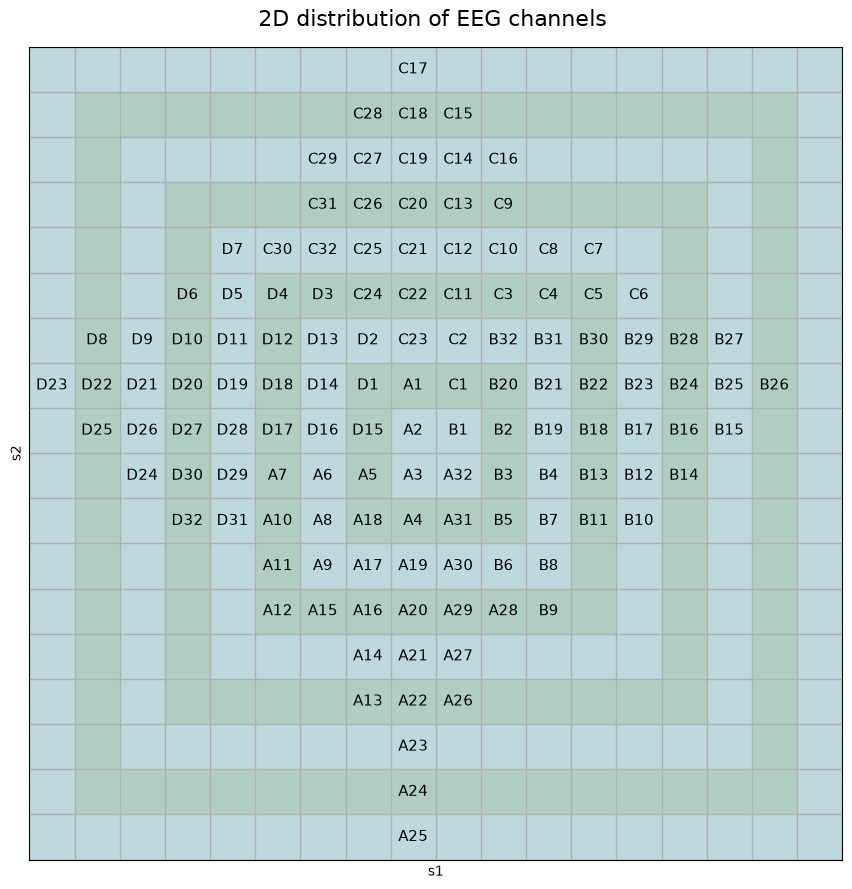

In [12]:
WINDOW_DURATION = 0.5
STEP_DURATION = 0.25

psd_array_assembly(
        window_duration = WINDOW_DURATION,
        step_duration = STEP_DURATION,
        channels_distribution = CENTRALIZED_ONE_BY_ONE_2D_DISTRIBUTION
)

# Stage 40: Obtain Indices

In [14]:

subjects = [
    f"sub-{i:02d}"
    for i in range(1, 11)
]

N_FOLDS = 6
VALIDATION_SIZE = 0.20
RANDOM_STATE = 42

obtain_indices(
    subjects=subjects,
    N_FOLDS=N_FOLDS,
    VALIDATION_SIZE=VALIDATION_SIZE,
    RANDOM_STATE=RANDOM_STATE,
)


######################################################################
SUBJECT: sub-01
######################################################################
PSD array shape: (100, 18, 18, 65, 9)
Labels shape: (100,)
Min: 0.0
Max: 5.0901676981946255e-09
Mean: 3.3047786528423875e-13
Std: 3.771183479764897e-12
Non-zero values: 7488000
Non-zero proportion: 0.3950617283950617

FOLD 1/6
Total: 100
Training: 66
Validation: 17
Test: 17
Training (%): 0.66
Validation (%): 0.17
Test (%): 0.17
Indices saved: fold_1.npz

FOLD 2/6
Total: 100
Training: 66
Validation: 17
Test: 17
Training (%): 0.66
Validation (%): 0.17
Test (%): 0.17
Indices saved: fold_2.npz

FOLD 3/6
Total: 100
Training: 66
Validation: 17
Test: 17
Training (%): 0.66
Validation (%): 0.17
Test (%): 0.17
Indices saved: fold_3.npz

FOLD 4/6
Total: 100
Training: 66
Validation: 17
Test: 17
Training (%): 0.66
Validation (%): 0.17
Test (%): 0.17
Indices saved: fold_4.npz

FOLD 5/6
Total: 100
Training: 67
Validation: 17
Test: 16
Training (

# Stage 50: Execute Branch

In [2]:

# ======================================================
# BRANCH OPTIONS
# ======================================================
#
# space1_space2_frequency_time
#
# space1_space2_time_frequency
#
# time_frequency_space2_space1
#
# time_frequency_space1_space2
#
# ======================================================

# subjects = [
#     f"sub-{i:02d}"
#     for i in range(1, 11)
# ]
subjects = ["sub-01"]

branches = [
    "space1_space2_frequency_time", 
    "space1_space2_time_frequency", 
    "time_frequency_space2_space1", 
    "time_frequency_space1_space2" 
]

for subject in subjects:
    for branch in branches:

        execute_branch(
            branch=branch,
            N_EPOCHS=600,       
            subjects= subject
        )


######################################################################
SUJEITO: sub-01
######################################################################
Chosen PRONOUNCED_SPEECH models
PSD Array: (100, 18, 18, 65, 9)
Labels: (100,)
Power reorganizado: (100, 9, 65, 18, 18)
X: torch.Size([100, 9, 65, 18, 18])
y: torch.Size([100])
Min: 0.0
Max: 5.090167842780602e-09
Mean: 3.304778868097602e-13
Std: 3.771183452322413e-12
Valores diferentes de zero: 7488000
Proporção diferente de zero: 0.3950617283950617
Device: cuda
CUDA disponível: True
Versão CUDA: 13.0
GPU: NVIDIA GeForce RTX 5070

FOLD 1/6
Total: 100
Treinamento: 66
Validação: 17
Teste: 17
Treinamento (%): 0.66
Validação (%): 0.17
Teste (%): 0.17
Power max: 5.090167842780602e-09
X_train: torch.Size([66, 9, 65, 18, 18])
X_val: torch.Size([17, 9, 65, 18, 18])
X_test: torch.Size([17, 9, 65, 18, 18])
Summary successfully saved to PDF without glitches: /home/jobson/Documentos/ESPECT_CONV/processed_data/stage_50_execute_branch/space1_s

# Stage 60: Execute Fusion

In [2]:

# ======================================================
# BRANCH_MODEL_STATE OPTIONS
# ======================================================
#
# minimum_loss_model
#
# maximum_accuracy_model
#
# ======================================================

# ======================================================
# FUSION OPTIONS
# ======================================================
#
# mean_fusion
# concatenation_fusion
# multiplication_fusion
# multiplication_log_softmax_fusion
# weighted_sum_fusion
# scalar_gated_fusion
# class_wise_gated_fusion
#
#
# ======================================================


# subjects = [
#     f"sub-{i:02d}"
#     for i in range(1, 11)
# ]
subjects = ["sub-01"]

branch_mode_states = ["minimum_loss_model", "maximum_accuracy_model"]

fusions = [
    "mean_fusion",
    "concatenation_fusion",
    "weighted_sum_fusion",
    "scalar_gated_fusion",
    "class_wise_gated_fusion"
]


for subject in subjects:
    for branch_mode_state in branch_mode_states:
        for fusion in fusions:

            execute_fusion(
                fusion= fusion,
                branch_model_state = branch_mode_state,
                subjects=subject,
                condition_folder = CONDITION,
                N_EPOCHS_STAGE_1 = 6,
                N_EPOCHS_STAGE_2 = 3,
                LEARNING_RATE_STAGE_1 = 0.001,
                LEARNING_RATE_STAGE_2 = 0.0001
            )

NameError: name 'CONDITION' is not defined